# Asistente turístico conversacional de Tenerife

**Proyecto final · Large Language Models**

Asistente que combina **RAG** (sobre la guía turística de Tenerife), **memoria
multiturno** y **llamadas a funciones externas** (`get_weather`).

Implementado con el mismo stack del material del curso: **LangChain + LangGraph**
con **Google Gemini** (`init_chat_model`, `GoogleGenerativeAIEmbeddings`,
`PyPDFLoader`, `RecursiveCharacterTextSplitter`, `FAISS`, `StateGraph`). Toda la
lógica vive en `src/`; este notebook **orquesta** las piezas.

### Índice
0. Requisitos previos
1. Configuración y variables de entorno
2. Carga de la guía y *chunking*
3. Indexado (embeddings + FAISS persistido en carpeta)
4. Herramienta `get_weather`
5. Montaje del asistente (grafo de LangGraph: RAG + memoria + function calling)
6. Conversación de ejemplo (multiturno + ≥3 *function calls*, con un fallo)
7. Evaluación reproducible (métricas + gráfico)
8. Análisis crítico

> **Nota.** Las celdas que llaman a la API (Gemini, embeddings, Open-Meteo) se
> ejecutan en tu máquina con tu clave; aquí van listas para ejecutar.


## 0. Requisitos previos

1. Instala dependencias: `pip install -r requirements.txt`
2. Coloca la guía `TENERIFE.pdf` en `data/`.
3. Crea tu `.env`: `cp .env.example .env` y añade tu clave
   (`GOOGLE_API_KEY`; el proveedor por defecto es `google`).


In [1]:
# %pip install -r requirements.txt

## 1. Configuración y variables de entorno

La clave se lee del entorno (`.env`); si falta, se pide con `getpass` para no
escribirla nunca en el notebook.


In [2]:
import os, sys, getpass
sys.path.insert(0, os.path.abspath("."))

from src import config

env_var = config._PROVIDER_ENV_VAR[config.MODEL.provider]
if not os.getenv(env_var):
    os.environ[env_var] = getpass.getpass(f"Introduce tu {env_var}: ")

print("Proveedor:        ", config.MODEL.provider, f"({config.MODEL.model_provider})")
print("Modelo generativo:", config.MODEL.generation_model)
print("Modelo embeddings:", config.MODEL.embedding_model)
print("Temperatura:      ", config.MODEL.temperature, "| top_p:", config.MODEL.top_p, "| max_tokens:", config.MODEL.max_output_tokens)
print("Clave cargada:    ", "sí" if os.getenv(env_var) else "NO")


Proveedor:         google (google_genai)
Modelo generativo: gemini-2.5-flash
Modelo embeddings: models/gemini-embedding-001
Temperatura:       0.2 | top_p: 0.95 | max_tokens: 800
Clave cargada:     sí


## 2. Carga de la guía y *chunking*

Cargamos el PDF con `PyPDFLoader` y troceamos con `RecursiveCharacterTextSplitter`
(`chunk_size=500`, `chunk_overlap=80`), añadiendo `chunk_id` y `source_name` a
cada fragmento para poder citar la fuente (página y nº de chunk).


In [3]:
from src.ingest import build_splits_from_pdf
from src.config import RAG, PATHS

splits = build_splits_from_pdf(PATHS.pdf_path, chunk_size=RAG.chunk_size, chunk_overlap=RAG.chunk_overlap)

print(f"Número de chunks: {len(splits)}")
print("\nEjemplo de chunk:\n", splits[0].page_content[:200], "...")
print("\nMetadata:", splits[0].metadata)


Número de chunks: 47

Ejemplo de chunk:
 TENERIFE – LUGARES DE INTERÉS 
SITIOS QUE VER 
 
ZONA NORTE 
 
• Santa Cruz de Tenerife: 
Santa Cruz de Tenerife es la capital de la isla. Quizás la ruta a seguir si vais a Santa 
Cruz sería: 
- Aparc ...

Metadata: {'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2025-07-13T20:00:01+00:00', 'title': 'Microsoft Word - TENERIFE.docx', 'moddate': '2025-07-13T20:00:01+00:00', 'source': 'C:\\github_pontia\\llm\\large-language-models\\data\\TENERIFE.pdf', 'total_pages': 25, 'page': 0, 'page_label': '1', 'start_index': 0, 'chunk_id': 0, 'source_name': 'TENERIFE.pdf'}


## 3. Indexado (embeddings + FAISS)

Generamos los embeddings con `GoogleGenerativeAIEmbeddings` y construimos un
índice **FAISS**, que se **persiste en una carpeta** (`storage/faiss/` con
`index.faiss` + `index.pkl`) mediante `save_local`, igual que el material del
curso. En ejecuciones posteriores se recarga con `load_local`.

> ⚠️ El índice depende del modelo de embeddings. Si cambias de proveedor,
> reconstrúyelo con `force_rebuild=True` (o borra `storage/faiss/`).


In [4]:
from src.indexing import build_embeddings, build_or_load_index

api_key = config.get_api_key(config.MODEL.provider)
embeddings = build_embeddings(api_key)

vector_store = build_or_load_index(
    splits, embeddings, faiss_dir=PATHS.faiss_dir, force_rebuild=False,
)
print("Índice FAISS listo. Carpeta:", PATHS.faiss_dir)
print("Archivos:", [p.name for p in PATHS.faiss_dir.iterdir()])


Índice FAISS listo. Carpeta: C:\github_pontia\llm\large-language-models\storage\faiss
Archivos: ['index.faiss', 'index.pkl']


**Comprobación de la recuperación.** Qué fragmentos trae para una consulta:

In [5]:
from src.rag import format_docs_with_sources

docs = vector_store.similarity_search("playa de arena negra para ver el atardecer", k=3)
print(format_docs_with_sources(docs)[:600])


[Fuente 1: TENERIFE.pdf, página 7, chunk 9]
o Playa de Benijo [vídeo - ubicación] 
Playa de arena negra, si el día está despejado, de los atardeceres más 
espectaculares que podéis ver en la isla. 
Para llegar a esta playa, aparcar por aquí y, para acceder a la playa, se accede 
desde aquí (puede ser que os encontréis con el acceso cortado con una valla, 
pero da igual, podéis acceder igualmente). 
• La Orotava 
Este es el pueblo más bonito y maravilloso del mundo (no es porque yo sea de allí).

[Fuente 2: TENERIFE.pdf, página 8, chunk 12]
Nacional) se hace una alfombra gigante de arenas y tie


## 4. Herramienta `get_weather`

Definida con **Pydantic** y envuelta como herramienta de LangChain. Consulta
**Open-Meteo** (sin clave) con *fallback* simulado, maneja errores y registra
cada intento en `logs/weather.log`. La probamos directamente (sin LLM).


In [6]:
from src.tools.weather import get_weather

print("OK   ->", get_weather("2026-06-25", "Teide", use_real_api=False))   # simulado
print("FALLO->", get_weather("30/02/2026", "Teide", use_real_api=False))   # fecha inválida


2026-06-16 09:27:05,896 | INFO | get_weather solicitado | args={'fecha': '2026-06-25', 'lugar': 'Teide'}
2026-06-16 09:27:05,897 | INFO | get_weather (simulado) | {'ok': True, 'fuente': 'simulada (sin conexión)', 'lugar': 'Teide', 'fecha': '2026-06-25', 'temp_min_c': 14, 'temp_max_c': 23, 'descripcion': 'lluvia ligera'}
2026-06-16 09:27:05,897 | INFO | get_weather solicitado | args={'fecha': '30/02/2026', 'lugar': 'Teide'}
2026-06-16 09:27:05,898 | WARNING | get_weather validación | {'ok': False, 'error': 'fecha_o_lugar_invalido', 'mensaje': "Value error, La fecha '30/02/2026' no es válida. Usa YYYY-MM-DD."}


OK   -> {'ok': True, 'fuente': 'simulada (sin conexión)', 'lugar': 'Teide', 'fecha': '2026-06-25', 'temp_min_c': 14, 'temp_max_c': 23, 'descripcion': 'lluvia ligera'}
FALLO-> {'ok': False, 'error': 'fecha_o_lugar_invalido', 'mensaje': "Value error, La fecha '30/02/2026' no es válida. Usa YYYY-MM-DD."}


## 5. Montaje del asistente

`TenerifeAssistant.from_config()` construye/carga el índice, crea el modelo con
`init_chat_model` y compila el **grafo de LangGraph** (`retrieve → generate →
tools → generate`) con memoria (`MemorySaver`). El modelo decide cuándo llamar
a `get_weather`.


In [7]:
from src.assistant import TenerifeAssistant

asistente = TenerifeAssistant.from_config(use_real_weather=True)
print(asistente.welcome())


¡Hola! 🌋 Soy tu asistente turístico de Tenerife. Respondo a partir de una guía de la isla y siempre te cito de dónde saco la información.

Puedes preguntarme cosas como:
  • ¿Qué playa de arena negra recomiendas para ver el atardecer?
  • ¿Dónde puedo comer en la zona norte?
  • ¿Por qué carretera se sube al Teide?
  • Recomiéndame un guachinche.
  • ¿Qué tiempo hará el sábado para subir al Teide?

Si algo no está en la guía, te lo diré en lugar de inventarlo.



## 6. Conversación de ejemplo

| Turno | Pregunta | Qué demuestra |
|------|----------|---------------|
| 1 | ¿Qué ver en la zona norte? | **RAG** + cita |
| 2 | ¿Y dónde como por allí? | **Memoria** |
| 3 | ¿Qué tiempo hará el sábado en el Teide? | **Function call** #1 (correcta) |
| 4 | ¿Y el domingo en La Orotava? | **Function call** #2 (correcta) |
| 5 | ¿Y pasado mañana en Santa Cruz? | **Function call** #3 (correcta) |
| 6 | ¿Y dentro de un año en Garachico? | **Function call** #4 → **fallo gestionado** |


In [8]:
from datetime import date, timedelta

def proximo(dia_semana: int) -> str:
    hoy = date.today()
    return (hoy + timedelta(days=(dia_semana - hoy.weekday()) % 7 or 7)).isoformat()

def turno(pregunta: str):
    t = asistente.chat(pregunta)
    print(f"👤 {pregunta}\n\n🤖 {t.answer}\n")
    if t.citations:
        print("   📚 Fuentes:", " | ".join(t.citations))
    for tc in t.tool_calls:
        print(f"   🔧 {tc.name}({tc.arguments}) -> {tc.result}")
    print(f"   ⏱️  {t.latency_ms} ms")
    print("-" * 80)
    return t


In [9]:
asistente.reset()
_ = turno("¿Qué cosas puedo ver en la zona norte de Tenerife?")


👤 ¿Qué cosas puedo ver en la zona norte de Tenerife?

🤖 ¡Hola! En la zona norte de Tenerife tienes varias opciones interesantes para visitar:

*   **Santa Cruz de Tenerife**: Es la capital de la isla. Te sugiero aparcar en el aparcamiento del Parque Marítimo, caminar por la Avenida Marítima hasta la Plaza de España, y por el camino, ver el Auditorio de Tenerife. Una vez en Plaza España, puedes callejear un poco y subir la Calle Castillo. (Fuente 2)
*   **Puerto de La Cruz**: Es la zona turística del Norte. Te recomiendo aparcar en la explanada del muelle e ir caminando desde allí hasta la Playa Martiánez. (Fuente 1)
*   **Icod**: Aquí puedes visitar el Parque del Drago (no estoy segura si se requiere entrada) y el Mariposario del Drago, donde verás muchas mariposas distintas (puedes consultar las entradas). También está la Casa del Plátano. (Fuente 3)
*   **Garachico**: Si bajas a Garachico, puedes ir hacia el Castillo de San Miguel, donde se encuentran las Piscinas Naturales del Calet

In [10]:
_ = turno("¿Y dónde puedo comer bien por allí?")

👤 ¿Y dónde puedo comer bien por allí?

🤖 ¡Claro que sí! En la zona norte de Tenerife tienes varias opciones estupendas para comer:

*   **Terrazas del Sauzal** (en El Sauzal, entre La Laguna y La Orotava): Tienen unas vistas espectaculares y están en la Guía Michelín. (Fuente 2)
*   **La Baranda** (también en El Sauzal): Otro sitio con vistas espectaculares, ideal para desayunar o merendar. (Fuente 2)
*   **Restaurante Las Vistas** (en Santa Úrsula, cerca de La Orotava). (Fuente 2)
*   **El Calderito de la Abuela** (en Santa Úrsula). (Fuente 3)
*   **Guachinche El Cubano** (en Santa Úrsula): Para llegar, atravesarás un camino de tierra, ¡pero no te asustes! Si vas a Tenerife y no pruebas un guachinche, no has estado en Tenerife. No tienen carta, así que es una experiencia auténtica. (Fuente 3)
*   **Arepera La Carajita** (entre La Orotava y el Puerto de la Cruz): Dicen que tienen las mejores arepas que podrás comer en tu vida y son baratísimas. Te recomiendo La Fogalera y Reina Pepiada

In [11]:
_ = turno(f"¿Qué tiempo hará el sábado {proximo(5)} para subir al Teide?")

2026-06-16 09:27:17,322 | INFO | get_weather solicitado | args={'fecha': '2026-06-20', 'lugar': 'El Teide'}
2026-06-16 09:27:17,629 | WARNING | get_weather lugar | {'ok': False, 'error': 'lugar_no_encontrado', 'mensaje': "No se encontró el lugar 'El Teide'."}


👤 ¿Qué tiempo hará el sábado 2026-06-20 para subir al Teide?

🤖 ¡Uy! Lo siento, no tengo información específica sobre el tiempo para "El Teide" en mi sistema. ¿Te gustaría que buscara el tiempo para alguna localidad cercana o para el Parque Nacional del Teide en general?

   📚 Fuentes: TENERIFE.pdf, pág. 14, chunk 24 | TENERIFE.pdf, pág. 15, chunk 26 | TENERIFE.pdf, pág. 14, chunk 23 | TENERIFE.pdf, pág. 4, chunk 7
   🔧 get_weather({'fecha': '2026-06-20', 'lugar': 'El Teide'}) -> {"ok": false, "error": "lugar_no_encontrado", "mensaje": "No se encontró el lugar 'El Teide'."}
   ⏱️  2397.5 ms
--------------------------------------------------------------------------------


In [12]:
_ = turno(f"¿Y el domingo {proximo(6)} en La Orotava?")

2026-06-16 09:27:19,984 | INFO | get_weather solicitado | args={'fecha': '2026-06-21', 'lugar': 'La Orotava'}
2026-06-16 09:27:20,578 | INFO | get_weather OK | {'ok': True, 'fuente': 'Open-Meteo', 'lugar': 'La Orotava', 'fecha': '2026-06-21', 'temp_min_c': 16.6, 'temp_max_c': 26.1, 'prob_precipitacion_pct': 0, 'descripcion': 'despejado'}


👤 ¿Y el domingo 2026-06-21 en La Orotava?

🤖 El domingo 21 de junio de 2026 en La Orotava hará un tiempo despejado, con una temperatura mínima de 16.6°C y una máxima de 26.1°C. La probabilidad de precipitación es del 0%. (Fuente: Open-Meteo)

   📚 Fuentes: TENERIFE.pdf, pág. 8, chunk 11 | TENERIFE.pdf, pág. 4, chunk 7 | TENERIFE.pdf, pág. 8, chunk 12 | TENERIFE.pdf, pág. 8, chunk 10
   🔧 get_weather({'fecha': '2026-06-21', 'lugar': 'La Orotava'}) -> {"ok": true, "fuente": "Open-Meteo", "lugar": "La Orotava", "fecha": "2026-06-21", "temp_min_c": 16.6, "temp_max_c": 26.1, "prob_precipitacion_pct": 0, "descripcion": "despejado"}
   ⏱️  2832.8 ms
--------------------------------------------------------------------------------


In [13]:
_ = turno(f"¿Y pasado mañana {(date.today()+timedelta(days=2)).isoformat()} en Santa Cruz de Tenerife?")

2026-06-16 09:27:22,660 | INFO | get_weather solicitado | args={'fecha': '2026-06-18', 'lugar': 'Santa Cruz de Tenerife'}
2026-06-16 09:27:23,250 | INFO | get_weather OK | {'ok': True, 'fuente': 'Open-Meteo', 'lugar': 'Santa Cruz de Tenerife', 'fecha': '2026-06-18', 'temp_min_c': 18.6, 'temp_max_c': 24.2, 'prob_precipitacion_pct': 8, 'descripcion': 'llovizna ligera'}


👤 ¿Y pasado mañana 2026-06-18 en Santa Cruz de Tenerife?

🤖 ¡Hola! Pasado mañana, el 18 de junio de 2026, en Santa Cruz de Tenerife, se espera llovizna ligera. La temperatura mínima será de 18.6°C y la máxima de 24.2°C. La probabilidad de precipitación es del 8%. (Fuente: Open-Meteo)

   📚 Fuentes: TENERIFE.pdf, pág. 4, chunk 7 | TENERIFE.pdf, pág. 0, chunk 0 | TENERIFE.pdf, pág. 2, chunk 3 | TENERIFE.pdf, pág. 24, chunk 46
   🔧 get_weather({'fecha': '2026-06-18', 'lugar': 'Santa Cruz de Tenerife'}) -> {"ok": true, "fuente": "Open-Meteo", "lugar": "Santa Cruz de Tenerife", "fecha": "2026-06-18", "temp_min_c": 18.6, "temp_max_c": 24.2, "prob_precipitacion_pct": 8, "descripcion": "llovizna ligera"}
   ⏱️  2703.7 ms
--------------------------------------------------------------------------------


In [14]:
_ = turno(f"¿Y el {(date.today()+timedelta(days=365)).isoformat()} en Garachico?")  # fallo gestionado (fuera del rango de 16 días)

2026-06-16 09:27:25,593 | INFO | get_weather solicitado | args={'fecha': '2027-06-16', 'lugar': 'Garachico'}
2026-06-16 09:27:25,594 | WARNING | get_weather validación | {'ok': False, 'error': 'fecha_o_lugar_invalido', 'mensaje': 'Value error, Solo hay previsión hasta 16 días vista (hasta 2026-07-02).'}


👤 ¿Y el 2027-06-16 en Garachico?

🤖 ¡Vaya! Lo siento, pero solo tengo previsión del tiempo hasta 16 días vista. No puedo darte la previsión para el 16 de junio de 2027 en Garachico.

   📚 Fuentes: TENERIFE.pdf, pág. 11, chunk 20 | TENERIFE.pdf, pág. 11, chunk 19 | TENERIFE.pdf, pág. 4, chunk 7 | TENERIFE.pdf, pág. 11, chunk 17
   🔧 get_weather({'lugar': 'Garachico', 'fecha': '2027-06-16'}) -> {"ok": false, "error": "fecha_o_lugar_invalido", "mensaje": "Value error, Solo hay previsión hasta 16 días vista (hasta 2026-07-02)."}
   ⏱️  2500.7 ms
--------------------------------------------------------------------------------


## 7. Evaluación reproducible

Batería fija de 9 prompts (7 RAG + 1 fuera de corpus + 1 de tiempo). Para cada
uno medimos **hit** de recuperación, **cita** y **corrección**. La evaluación
reinicia la memoria por prompt y usa temperatura baja.


In [15]:
CASOS = [
    {"pregunta": "¿Qué playa de arena negra recomiendas para ver el atardecer?", "claves": ["benijo"], "tipo": "rag"},
    {"pregunta": "¿Dónde puedo comer batata con almogrote?", "claves": ["casiano", "almogrote"], "tipo": "rag"},
    {"pregunta": "¿Cuál es el mejor parque acuático y qué récords tiene?", "claves": ["siam"], "tipo": "rag"},
    {"pregunta": "¿Cómo se llega actualmente a Punta de Teno?", "claves": ["369", "titsa"], "tipo": "rag"},
    {"pregunta": "¿Qué curiosidad tiene el reloj de la Iglesia de la Concepción de La Laguna?", "claves": ["iiii"], "tipo": "rag"},
    {"pregunta": "¿Por qué carretera recomienda subir al Teide?", "claves": ["tf24", "anchieta"], "tipo": "rag"},
    {"pregunta": "Recomiéndame un guachinche.", "claves": ["cubano", "guachinche"], "tipo": "rag"},
    {"pregunta": "¿Qué pueblos bonitos hay para visitar en la isla de La Gomera?", "claves": [], "tipo": "fuera_corpus"},
    {"pregunta": "¿Qué tiempo hará el sábado para subir al Teide?", "claves": [], "tipo": "weather"},
]
NEGATIVAS = ["no tengo", "no encuentro", "no aparece", "no dispongo", "no figura", "no se menciona"]

def evaluar_caso(caso):
    asistente.reset()
    # hit: ¿algún fragmento recuperado contiene las claves?
    docs = asistente.vector_store.similarity_search(caso["pregunta"], k=RAG.top_k)
    texto = " ".join(d.page_content.lower() for d in docs)
    hit = all(k in texto for k in caso["claves"]) if caso["claves"] else None

    t = asistente.chat(caso["pregunta"])
    ans = t.answer.lower()
    cita = "fuente" in ans or bool(t.citations)

    if caso["tipo"] == "rag":
        correcto = all(k in ans for k in caso["claves"])
    elif caso["tipo"] == "fuera_corpus":
        correcto = any(n in ans for n in NEGATIVAS)
        cita = any(n in ans for n in NEGATIVAS)  # debe admitir, no citar/inventar
    else:
        correcto = any(tc.name == "get_weather" for tc in t.tool_calls)

    return {"pregunta": caso["pregunta"][:42] + "...", "tipo": caso["tipo"], "hit": hit,
            "cita": cita, "correcto": correcto,
            "herramienta": ",".join(tc.name for tc in t.tool_calls) or "-",
            "latencia_ms": t.latency_ms}


In [16]:
import pandas as pd
df = pd.DataFrame([evaluar_caso(c) for c in CASOS])
df


,pregunta,tipo,hit,cita,correcto,herramienta,latencia_ms
0,¿Qué playa de arena negra recomiendas para...,rag,True,True,True,-,3855.0
1,¿Dónde puedo comer batata con almogrote?...,rag,True,True,True,-,1815.9
2,¿Cuál es el mejor parque acuático y qué ré...,rag,True,True,True,-,1412.9
3,¿Cómo se llega actualmente a Punta de Teno...,rag,True,True,True,-,1114.6
4,¿Qué curiosidad tiene el reloj de la Igles...,rag,True,True,True,-,2330.5
5,¿Por qué carretera recomienda subir al Tei...,rag,True,True,True,-,897.8
6,Recomiéndame un guachinche....,rag,True,True,True,-,3715.6
7,¿Qué pueblos bonitos hay para visitar en l...,fuera_corpus,None,True,True,-,1059.2
8,¿Qué tiempo hará el sábado para subir al T...,weather,None,True,False,-,1927.7


In [17]:
rag_df = df[df.tipo == "rag"]
print(f"Recuperación correcta (hit): {rag_df.hit.mean():.0%}")
print(f"Tasa de citación:            {df.cita.mean():.0%}")
print(f"Respuesta correcta (RAG):    {rag_df.correcto.mean():.0%}")
print(f"Global - correctas:          {df.correcto.mean():.0%}")
print(f"Latencia media:              {df.latencia_ms.mean():.0f} ms")


Recuperación correcta (hit): 100%
Tasa de citación:            100%
Respuesta correcta (RAG):    100%
Global - correctas:          89%
Latencia media:              2014 ms


**Gráfico.** Tasas agregadas y latencia por prompt.

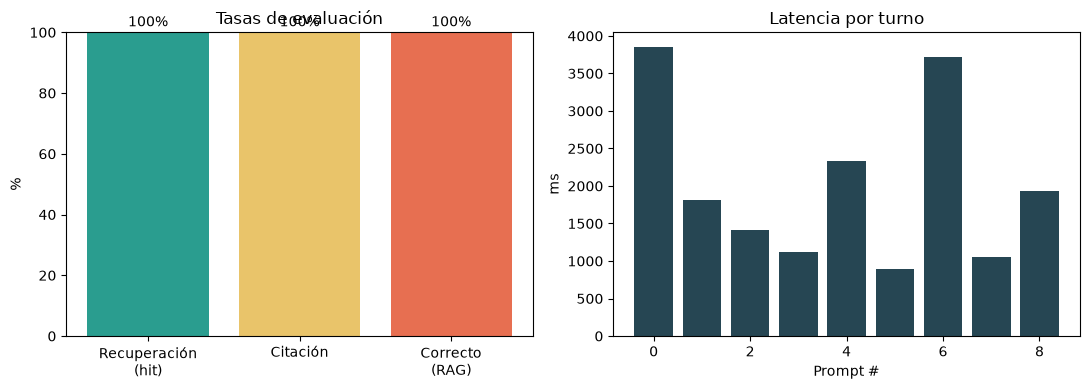

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
metricas = {"Recuperación\n(hit)": rag_df.hit.mean(), "Citación": df.cita.mean(), "Correcto\n(RAG)": rag_df.correcto.mean()}
ax1.bar(metricas.keys(), [v*100 for v in metricas.values()], color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax1.set_ylim(0, 100); ax1.set_ylabel("%"); ax1.set_title("Tasas de evaluación")
for i, v in enumerate(metricas.values()):
    ax1.text(i, v*100 + 2, f"{v:.0%}", ha="center")
ax2.bar(range(len(df)), df.latencia_ms, color="#264653")
ax2.set_xlabel("Prompt #"); ax2.set_ylabel("ms"); ax2.set_title("Latencia por turno")
plt.tight_layout(); plt.show()


## 8. Análisis crítico

**Casos límite**
- *Referencias anafóricas* ("¿y por allí?"): se resuelven con la memoria del grafo
  (checkpointer por `thread_id`).
- *Fuera de corpus*: el *system prompt* obliga a admitir que no está en la guía;
  evita alucinaciones.
- *Fechas en `get_weather`*: la validación Pydantic atrapa fechas inválidas,
  pasadas o fuera del rango de 16 días, devolviendo un mensaje útil.

**Limitaciones**
- El conocimiento se limita a la guía (sin precios/horarios salvo los que incluya).
- El *chunking* por caracteres puede cortar a mitad de frase; el solapamiento lo mitiga.
- El recuento de tokens para recortar el historial es aproximado.

**Mejoras futuras**
- *Re-ranking* de los fragmentos recuperados.
- Recuperación híbrida (densa + BM25).
- Más herramientas (horarios de guaguas, eventos) y multimodalidad (imágenes).
- Evaluación asistida por LLM (fidelidad/*groundedness*).
